# QVC vacuum bridge + TQGL $G_{ij}$ lab

Frozen-cavity derivation: $\alpha = E_{\mathrm{vac}}/\Delta_0$, $\ell=\ln(\Delta_0 r/(2\hbar c_s))+\gamma_E$.
Open in Jupyter Lab from the QVCCompute root after `pip install -e .` (or use `.venv`).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if (Path.cwd()/"qvc").exists() else Path.cwd().parent))

from qvc.bridge import derive_bridge
from qvc.gij_tqgl_ws import run_tqgl_ws_G
from qvc.gap_fold import fold_curve
import matplotlib.pyplot as plt
import numpy as np

b = derive_bridge()
print("ell_frozen", b["ell_frozen"])
print("F", b["F"], "E_vac", b["E_vac_meV"], "meV")
print("alpha/ac", b["alpha_over_ac"], "folded_out", b["folded_out"])
print("replaces 0.244 with", b["E_vac_meV"])

ell_frozen -2.7958108397939263
F 0.5806751779874608 E_vac 0.12870089825559464 meV
alpha/ac 1.179904766358088 folded_out True
replaces 0.244 with 0.12870089825559464


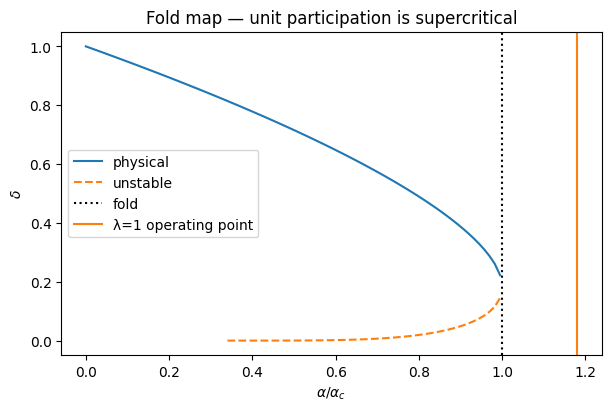

In [2]:
curve = fold_curve(ell=b["ell_frozen"], n=80)
a = np.array(curve["alpha_over_ac"])
phys = [np.nan if v is None else v for v in curve["delta_phys"]]
unst = [np.nan if v is None else v for v in curve["delta_unst"]]
fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)
ax.plot(a, phys, label="physical")
ax.plot(a, unst, "--", label="unstable")
ax.axvline(1.0, ls=":", color="k", label="fold")
ax.axvline(b["alpha_over_ac"], color="C1", label="λ=1 operating point")
ax.set_xlabel(r"$\alpha/\alpha_c$")
ax.set_ylabel(r"$\delta$")
ax.legend()
ax.set_title("Fold map — unit participation is supercritical")
plt.show()

acceptance {'hermitian': True, 'diag_zero': True, 'trace_zero': True, 'lambda_min_lt_0': True, 'near_democratic': True}
eigs [-0.0001556030690459934, -0.00015548445060664266, -0.00011474109806593923, -0.00011446613301977063, 0.0005402947507383456]


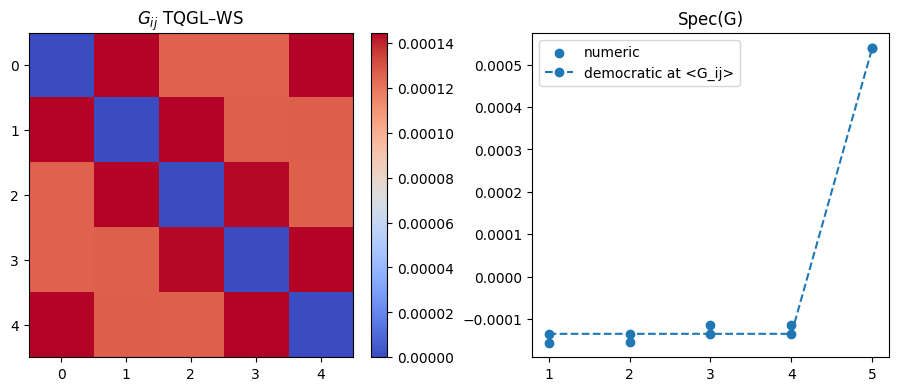

In [3]:
g = run_tqgl_ws_G(n_grid=36)
print("acceptance", g["acceptance"])
print("eigs", g["eigenvalues"])
G = np.array(g["G"])
fig, axes = plt.subplots(1, 2, figsize=(9,3.8), constrained_layout=True)
im = axes[0].imshow(G, cmap="coolwarm")
axes[0].set_title(r"$G_{ij}$ TQGL–WS")
fig.colorbar(im, ax=axes[0])
idx = np.arange(1, len(g["eigenvalues"])+1)
axes[1].scatter(idx, g["eigenvalues"], label="numeric")
dem = [g["democratic_lambda_min"]]*(len(idx)-1)+[g["democratic_lambda_max"]]
axes[1].plot(idx, dem, "o--", label="democratic at <G_ij>")
axes[1].legend()
axes[1].set_title("Spec(G)")
plt.show()